In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
import numpy as np
from pathlib import Path
import time
import matplotlib.pyplot as plt
import torch.nn.functional as F
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
import seaborn as sns


In [3]:
from model import IntentClassifier, BANKING77_CONFIG

In [4]:
BANKING77_LABELS = [
    "activate_my_card", "age_limit", "apple_pay_or_google_pay", "atm_support",
    "automatic_top_up", "balance_not_updated_after_bank_transfer",
    "balance_not_updated_after_cheque_or_cash_deposit", "beneficiary_not_allowed",
    "cancel_transfer", "card_about_to_expire", "card_acceptance",
    "card_arrival", "card_delivery_estimate", "card_linking", "card_not_working",
    "card_payment_fee_charged", "card_payment_not_recognised",
    "card_payment_wrong_exchange_rate", "card_swallowed", "cash_withdrawal_charge",
    "cash_withdrawal_not_recognised", "change_pin", "compromised_card",
    "contactless_not_working", "country_support", "declined_card_payment",
    "declined_cash_withdrawal", "declined_transfer", "direct_debit_payment_not_recognised",
    "disposable_card_limits", "edit_personal_details", "exchange_charge",
    "exchange_rate", "exchange_via_app", "extra_charge_on_statement",
    "failed_transfer", "fiat_currency_support", "get_disposable_virtual_card",
    "get_physical_card", "getting_spare_card", "getting_virtual_card",
    "lost_or_stolen_card", "lost_or_stolen_phone", "order_physical_card",
    "passcode_forgotten", "pending_card_payment", "pending_cash_withdrawal",
    "pending_top_up", "pending_transfer", "pin_blocked", "receiving_money",
    "refund_not_showing_up", "request_refund", "reverted_card_payment?",
    "romania_top_up", "Savings_session", "card_about_to_expire",
    "supported_cards_and_currencies", "terminate_account", "top_up_by_bank_transfer_charge",
    "top_up_by_card_charge", "top_up_by_cash_or_cheque", "top_up_failed",
    "top_up_limits", "top_up_reverted", "topping_up_by_card",
    "transaction_charged_twice", "transfer_fee_charged", "transfer_into_account",
    "transfer_not_received_by_recipient", "transfer_timing", "unable_to_verify_identity",
    "verify_my_identity", "verify_source_of_funds", "verify_top_up",
    "virtual_card_not_working", "visa_or_mastercard", "why_is_my_card_blocked",
]
 
ID2LABEL = {i: label for i, label in enumerate(BANKING77_LABELS)}

In [5]:
TRAIN_CONFIG = {
    "batch_size"   : 64,
    "epochs"       : 20, # 30 -> 20,we  were plateauing at 17-18 anyway
    "lr"           : 1e-4,
    "weight_decay" : 1e-2,
    "grad_clip"    : 1.0,
    "num_classes"  : 77,
    "pool"         : "mean",
    "seed"         : 42,
    "save_path"    : "best_model.pt",
    "train_emb"    : r"D:/@FYP-IntentClassifier/text-preprocessing/train_embeddings.pt",
    "val_emb"      : r"D:/@FYP-IntentClassifier/text-preprocessing/val_embeddings.pt",
    "test_emb"     : r"D:/@FYP-IntentClassifier/text-preprocessing/test_embeddings.pt",
}

In [6]:
class EmbeddingDataset(Dataset):
    """
    Expects a .pt file containing a dict:
        {
            "embeddings"     : Tensor[N, seq_len, emb_dim],
            "attention_mask" : Tensor[N, seq_len],   # 1 = real token, 0 = pad
            "labels"         : Tensor[N],
        }
    """
    def __init__(self, path: str):
        data = torch.load(path, weights_only=True)
        self.embeddings      = data["embeddings"]       # (N, seq_len, emb_dim)
        self.attention_mask  = data["attention_mask"]   # (N, seq_len)
        self.labels          = data["labels"]           # (N,)
 
    def __len__(self):
        return len(self.labels)
 
    def __getitem__(self, idx):
        return (
            self.embeddings[idx],
            self.attention_mask[idx],
            self.labels[idx],
        )
 

HELPERS

In [7]:
def set_seed(seed: int):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
 

In [8]:
def accuracy(logits: torch.Tensor, labels: torch.Tensor) -> float:
    preds = logits.argmax(dim=-1)
    return (preds == labels).float().mean().item()

In [9]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_acc, n = 0.0, 0.0, 0
    for emb, mask, labels in loader:
        emb, mask, labels = emb.to(device), mask.to(device), labels.to(device)
        logits = model(emb, mask)
        total_loss += criterion(logits, labels).item() * len(labels)
        total_acc  += accuracy(logits, labels)         * len(labels)
        n          += len(labels)
    return total_loss / n, total_acc / n
 

In [10]:
@torch.no_grad()
def predict(model, loader, device, id2label=None, threshold=0.4, temp=2.0, intent_thresholds=None):
    """
    Run inference and print confidence score + predicted intent per sample.
 
    Args:
        threshold : samples with max-softmax below this are marked REJECTED
        temp      : temperature for scaling logits (1.0 = no scaling)
                    tune this after training with compute_ece()
    """
    model.eval()
    results = []
    for emb, mask, labels in loader:
        emb, mask = emb.to(device), mask.to(device)
        logits = model(emb, mask)
        probs  = torch.softmax(logits / temp, dim=-1)
        confidence, predicted = probs.max(dim=-1)
 
        for i in range(len(labels)):
            conf  = confidence[i].item()
            pred  = predicted[i].item()
            true  = labels[i].item()
            label = id2label[pred] if id2label else str(pred)
            
            if intent_thresholds:
                thresh = intent_thresholds.get(label, threshold)
            else:
                thresh = threshold

            results.append({
                "predicted_id"    : pred,
                "predicted_label" : label,
                "confidence"      : round(conf, 4),
                "true_id"         : true,
                "correct"         : pred == true,
                "rejected"        : conf < thresh,      # ← now per-intent
                "threshold_used"  : round(thresh, 4),   # ← useful for debugging
            })
            
    print(f"\n{'STATUS':<32}{'CONFIDENCE':>12}  {'CORRECT':>8}  TRUE ID")
    print("-" * 70)
    for r in results[:20]:                          # show first 20
        if r["rejected"]:
            status = "REJECTED"
        else:
            status = r["predicted_label"]
        correct_str = "Y" if r["correct"] else "N"
        print(f"{status:<32}{r['confidence']:>12.4f}  {correct_str:>8}  {r['true_id']}")
 
    n_total    = len(results)
    n_rejected = sum(r["rejected"] for r in results)
    n_correct  = sum(r["correct"] and not r["rejected"] for r in results)
    print(f"\nTotal: {n_total}  |  Rejected: {n_rejected}  |  "
          f"Accepted correct: {n_correct}/{n_total - n_rejected}")
    return results

In [11]:
def compute_ece(results, n_bins=15):
    """
    Expected Calibration Error — measures how well confidence matches accuracy.
    Lower is better. A perfectly calibrated model has ECE = 0.
 
    Prints a reliability breakdown and returns the ECE scalar.
    """
    confidences = np.array([r["confidence"] for r in results])
    correctness = np.array([r["correct"]    for r in results], dtype=float)
 
    bins    = np.linspace(0, 1, n_bins + 1)
    ece     = 0.0
    n_total = len(results)
 
    print(f"\n{'BIN':>14}  {'COUNT':>6}  {'AVG CONF':>10}  {'ACCURACY':>10}  {'|DIFF|':>8}")
    print("-" * 58)
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (confidences > lo) & (confidences <= hi)
        if mask.sum() == 0:
            continue
        avg_conf = confidences[mask].mean()
        avg_acc  = correctness[mask].mean()
        weight   = mask.sum() / n_total
        diff     = abs(avg_conf - avg_acc)
        ece     += weight * diff
        print(f"({lo:.2f}, {hi:.2f}]  {mask.sum():>6}  {avg_conf:>10.4f}  "
              f"{avg_acc:>10.4f}  {diff:>8.4f}")
 
    print(f"\nECE = {ece:.4f}  (0 = perfect, >0.05 = needs calibration)")
    return ece

In [12]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience    = patience
        self.min_delta   = min_delta
        self.best_loss   = float("inf")
        self.counter     = 0
        self.should_stop = False

    def step(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

In [13]:
def train(cfg: dict = TRAIN_CONFIG):
    set_seed(cfg["seed"])
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}\n")
 
    # ── Data ──────────────────────────────────────────────────────────────────
    train_ds = EmbeddingDataset(cfg["train_emb"])
    val_ds = EmbeddingDataset(cfg["val_emb"])
    test_ds  = EmbeddingDataset(cfg["test_emb"])
 
    train_loader = DataLoader(
        train_ds,
        batch_size=cfg["batch_size"],
        shuffle=True,
        num_workers=0,
        pin_memory=True,
    )
    
    val_loader = DataLoader(
        val_ds,
        batch_size=cfg["batch_size"],
        shuffle=True,
        num_workers=0,
        pin_memory=True,
    )
    
    test_loader = DataLoader(
        test_ds,
        batch_size=cfg["batch_size"] * 2,
        shuffle=False,
        num_workers=0, #Windows issue
        pin_memory=True,
    )
 
    # ── Model ─────────────────────────────────────────────────────────────────
    model = IntentClassifier(
        cfg=BANKING77_CONFIG,
        num_classes=cfg["num_classes"],
        pool=cfg["pool"],
    ).to(device)
 
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {n_params:,}\n")
 
    # ── Optimiser & scheduler ─────────────────────────────────────────────────
    optimizer = AdamW(
        model.parameters(),
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"],
    )
 
    # OneCycleLR: warmup + cosine decay in one shot — works well for transformers
    scheduler = OneCycleLR(
        optimizer,
        max_lr=cfg["lr"],
        steps_per_epoch=len(train_loader),
        epochs=cfg["epochs"],
        pct_start=0.1,          # 10 % of steps = warmup
        anneal_strategy="cos",
    )
 
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
 
    # ── Loop ──────────────────────────────────────────────────────────────────
    best_acc   = 0.0
    history    = []
    early_stopping = EarlyStopping(patience=5)
 
    for epoch in range(1, cfg["epochs"] + 1):
        model.train()
        epoch_loss, epoch_acc, n = 0.0, 0.0, 0
        t0 = time.time()
 
        for emb, mask, labels in train_loader:
            emb, mask, labels = emb.to(device), mask.to(device), labels.to(device)
 
            optimizer.zero_grad()
            logits = model(emb, mask)
            loss   = criterion(logits, labels)
            loss.backward()
 
            nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
 
            optimizer.step()
            scheduler.step()
 
            bs = len(labels)
            epoch_loss += loss.item() * bs
            epoch_acc  += accuracy(logits, labels) * bs
            n          += bs
 
        train_loss = epoch_loss / n
        train_acc  = epoch_acc  / n
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        elapsed = time.time() - t0
 
        history.append({
            "epoch": epoch,
            "train_loss": train_loss, "train_acc": train_acc,
            "val_loss": val_loss,     "val_acc": val_acc,
        })
 
        flag = ""
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), cfg["save_path"])
            flag = "  ← saved"
 
        print(
            f"Epoch {epoch:02d}/{cfg['epochs']}  "
            f"train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  "
            f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}  "
            f"({elapsed:.1f}s){flag}"
        )
        
        early_stopping.step(val_loss)          # ADDED THIS
        if early_stopping.should_stop:         # ADDED THIS
            print(f"\nEarly stopping at epoch {epoch}")
            break
 
    print(f"\nBest val accuracy: {best_acc:.4f}")
    return history


In [ ]:
# ── Entry point ───────────────────────────────────────────────────────────────
 
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 
    # ── Train ──────────────────────────────────────────────────────────────────
    history = train()
 
    # ── Load best checkpoint ───────────────────────────────────────────────────
    model = IntentClassifier(
        cfg=BANKING77_CONFIG,
        num_classes=TRAIN_CONFIG["num_classes"],
        pool=TRAIN_CONFIG["pool"],
    ).to(device)
    model.load_state_dict(torch.load(TRAIN_CONFIG["save_path"], map_location=device))
 
    test_ds = EmbeddingDataset(TRAIN_CONFIG["test_emb"])
    test_loader = DataLoader(
        test_ds,
        batch_size=TRAIN_CONFIG["batch_size"] * 2,
        shuffle=False,
        num_workers=0,
    )
 
    # ── Confidence + intent predictions ───────────────────────────────────────
    print("\n" + "=" * 70)
    print("PREDICTIONS ")
    print("=" * 70)
    results = predict(
        model, test_loader, device,
        id2label=ID2LABEL,
        threshold=0.4,
        temp=1.0,           # set T > 1 if ECE shows overconfidence
    )
 
    # ── Calibration error ──────────────────────────────────────────────────────
    print("\n" + "=" * 70)
    print("CALIBRATION  (ECE)")
    print("=" * 70)
    ece = compute_ece(results)

Device: cuda

Trainable parameters: 14,825,549

Epoch 01/20  train_loss=4.2201  train_acc=0.0593  val_loss=3.6285  val_acc=0.1328  (33.8s)  ← saved
Epoch 02/20  train_loss=2.6461  train_acc=0.4242  val_loss=1.8050  val_acc=0.6829  (33.1s)  ← saved
Epoch 03/20  train_loss=1.5925  train_acc=0.7603  val_loss=1.4276  val_acc=0.8318  (33.2s)  ← saved
Epoch 04/20  train_loss=1.3195  train_acc=0.8459  val_loss=1.3844  val_acc=0.8538  (33.3s)  ← saved
Epoch 05/20  train_loss=1.1992  train_acc=0.8861  val_loss=1.3105  val_acc=0.8932  (33.3s)  ← saved
Epoch 06/20  train_loss=1.1024  train_acc=0.9177  val_loss=1.2777  val_acc=0.8852  (33.3s)
Epoch 07/20  train_loss=1.0535  train_acc=0.9331  val_loss=1.2768  val_acc=0.8865  (33.5s)
Epoch 08/20  train_loss=0.9984  train_acc=0.9521  val_loss=1.2306  val_acc=0.8965  (33.7s)  ← saved
Epoch 09/20  train_loss=0.9637  train_acc=0.9587  val_loss=1.2363  val_acc=0.9065  (34.1s)  ← saved
Epoch 10/20  train_loss=0.9316  train_acc=0.9723  val_loss=1.1998  val

In [18]:
def evaluate_on_test(model, test_loader, criterion, device, class_names=None):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []
    total_loss = 0.0

    with torch.no_grad():
        for emb, mask, labels in test_loader:  # matches your DataLoader format
            emb, mask, labels = emb.to(device), mask.to(device), labels.to(device)

            logits = model(emb, mask)  # matches your model's forward signature
            loss = criterion(logits, labels)
            total_loss += loss.item()

            probs = F.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    avg_loss = total_loss / len(test_loader)

    # --- Metrics ---
    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')

    print(f"\n{'='*50}")
    print(f"  TEST RESULTS")
    print(f"{'='*50}")
    print(f"  Loss         : {avg_loss:.4f}")
    print(f"  Accuracy     : {acc:.4f} ({acc*100:.2f}%)")
    print(f"  F1 (macro)   : {f1_macro:.4f}")
    print(f"  F1 (weighted): {f1_weighted:.4f}")
    print(f"{'='*50}\n")

    # --- Per-class report ---
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # --- Confusion Matrix ---
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix — Test Set')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150)
    plt.show()
    print("Confusion matrix saved to confusion_matrix.png")

    return {
        'loss': avg_loss, 'accuracy': acc,
        'f1_macro': f1_macro, 'f1_weighted': f1_weighted,
        'preds': all_preds, 'labels': all_labels, 'probs': all_probs
    }
    



  TEST RESULTS
  Loss         : 1.1619
  Accuracy     : 0.9138 (91.38%)
  F1 (macro)   : 0.9136
  F1 (weighted): 0.9136

Classification Report:
                                                  precision    recall  f1-score   support

                                activate_my_card       0.97      0.95      0.96        40
                                       age_limit       0.98      1.00      0.99        40
                         apple_pay_or_google_pay       1.00      1.00      1.00        40
                                     atm_support       1.00      1.00      1.00        39
                                automatic_top_up       0.95      0.88      0.91        40
         balance_not_updated_after_bank_transfer       0.91      0.72      0.81        40
balance_not_updated_after_cheque_or_cash_deposit       0.97      0.97      0.97        40
                         beneficiary_not_allowed       0.90      0.90      0.90        40
                                 cancel_tran

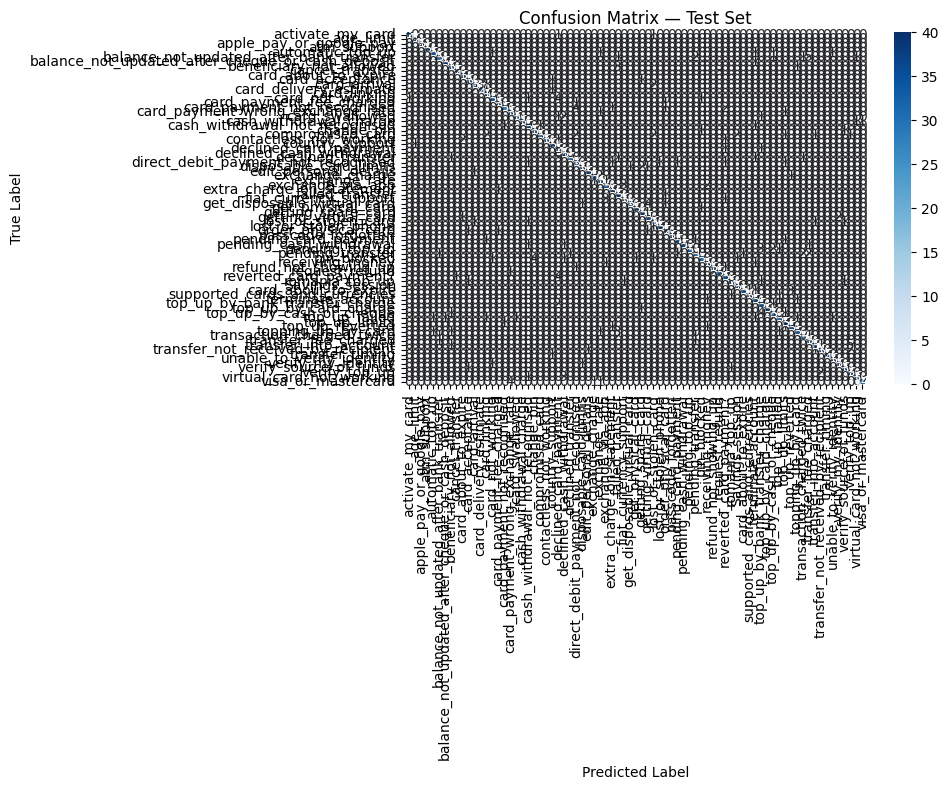

Confusion matrix saved to confusion_matrix.png


In [21]:
# ── Test set evaluation (separate cell) ───────────────────────────────────────

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

test_results = evaluate_on_test(
    model, test_loader, criterion, device,
    class_names=[ID2LABEL[i] for i in range(len(ID2LABEL) - 1)] 
)